**Welcome to CSE 430 Digital Signal Processing**

## Getting Started

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Discrete time signal vs Analog signal
- **Analog signal** -> $x(t)$, $t$ is continious, $x(t)$ is continious
- **Discrete time signal** -> $x[n]$, $n$ is discrete, $x[n]$ is continious

For discrete signal, <span style="color:red">$n = 0,~1,~2,~\cdots,~(N-1)$</span> where $N = \mathrm{length}(x)$

In [2]:
t = np.linspace(0, 1, 1000)          # Linearly spaced 1000 points within 1 second,in real,
                                    # 1000 should be replaced by infinity
x_ct = np.sin(2*np.pi*5*t)          # 5 Hz sine wave
# print(t)
print(x_ct)

[ 0.00000000e+00  3.14421909e-02  6.28532900e-02  9.42022363e-02
  1.25458030e-01  1.56589764e-01  1.87566653e-01  2.18358066e-01
  2.48933554e-01  2.79262883e-01  3.09316061e-01  3.39063370e-01
  3.68475395e-01  3.97523050e-01  4.26177612e-01  4.54410746e-01
  4.82194534e-01  5.09501500e-01  5.36304643e-01  5.62577458e-01
  5.88293965e-01  6.13428734e-01  6.37956911e-01  6.61854240e-01
  6.85097090e-01  7.07662479e-01  7.29528091e-01  7.50672305e-01
  7.71074213e-01  7.90713639e-01  8.09571163e-01  8.27628139e-01
  8.44866709e-01  8.61269828e-01  8.76821275e-01  8.91505673e-01
  9.05308500e-01  9.18216107e-01  9.30215731e-01  9.41295506e-01
  9.51444475e-01  9.60652602e-01  9.68910783e-01  9.76210851e-01
  9.82545587e-01  9.87908727e-01  9.92294968e-01  9.95699972e-01
  9.98120372e-01  9.99553775e-01  9.99998764e-01  9.99454898e-01
  9.97922715e-01  9.95403731e-01  9.91900435e-01  9.87416293e-01
  9.81955739e-01  9.75524172e-01  9.68127953e-01  9.59774394e-01
  9.50471757e-01  9.40229

The printed values don't give us any insight.
Visualize Visualize Visualize!

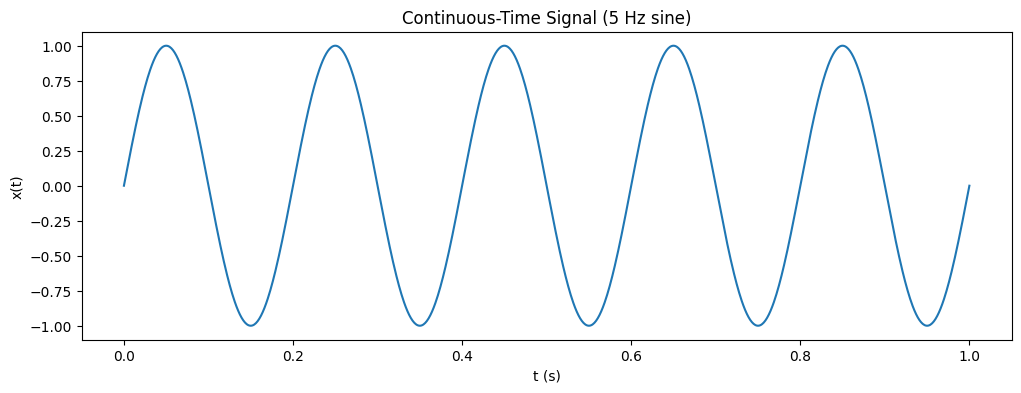

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(t, x_ct)
plt.title("Continuous-Time Signal (5 Hz sine)")
plt.xlabel("t (s)");
plt.ylabel("x(t)");

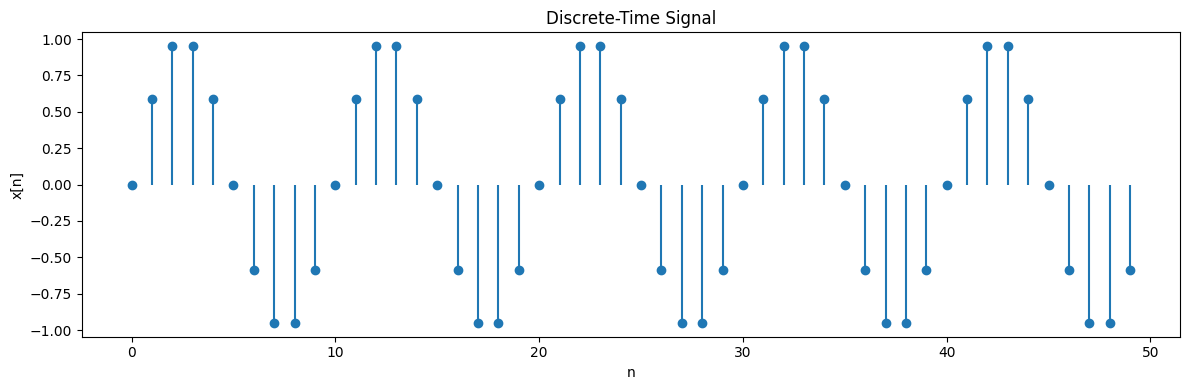

In [ ]:
n = np.arange(0, 50)                 # discrete time (0,1,2,..49)
x_dt = np.sin(2*np.pi*0.1*n)
plt.figure(figsize=(12,4))
plt.stem(n, x_dt, basefmt=" ")
plt.title("Discrete-Time Signal")
plt.xlabel("n"); plt.ylabel("x[n]")
plt.tight_layout()
plt.show()

## Sampling rate


The **sampling rate** ${f_s}$  defines how frequently we capture data points from a continuous signal.

We store values at regular intervals, determined by the **sampling period**:
$$ \
T_s = \frac{1}{f_s}$$

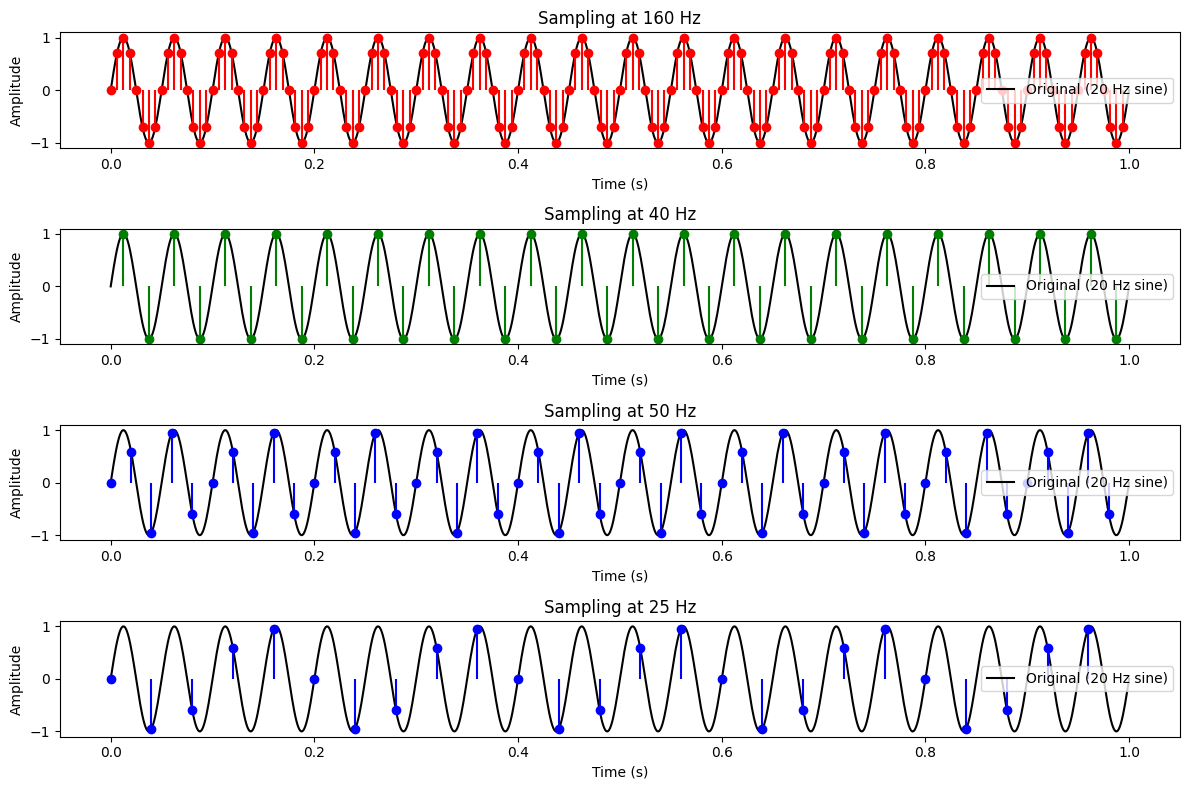

In [ ]:
# Original continuous signal
t_ct = np.linspace(0, 1, 1000) #in real, 1000 should be replaced by infinity
x_ct = np.sin(2*np.pi*20*t_ct)   # 20 Hz sine

# Sampling rates to compare
fs_list = [160, 40,50, 25]  # In Hz
colors = ["r", "g", "b","b"]

plt.figure(figsize=(12,8))
for i, fs in enumerate(fs_list, 1):
    n = np.arange(0, 1, 1/fs)
    if fs == 40: # No need to worry about this if condition now
                  # You can comment this condition and see what happens
        t0 = 1/(4*20)
        n = n + t0
    x_n = np.sin(2*np.pi*20*n)

    plt.subplot(4,1,i)
    plt.plot(t_ct, x_ct, 'k', label="Original (20 Hz sine)")
    plt.stem(n, x_n, linefmt=colors[i-1]+"-", markerfmt=colors[i-1]+"o", basefmt=" ")


    plt.title(f"Sampling at {fs} Hz")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
    plt.legend()

plt.tight_layout()
plt.show()

We can reconstruct the signal from the sampled  version. Most of the cases, interpolation is used. But we have an advantage in matplotlib. If we use plt.plot instead of plt.steam, the signal is automatically interpolated.

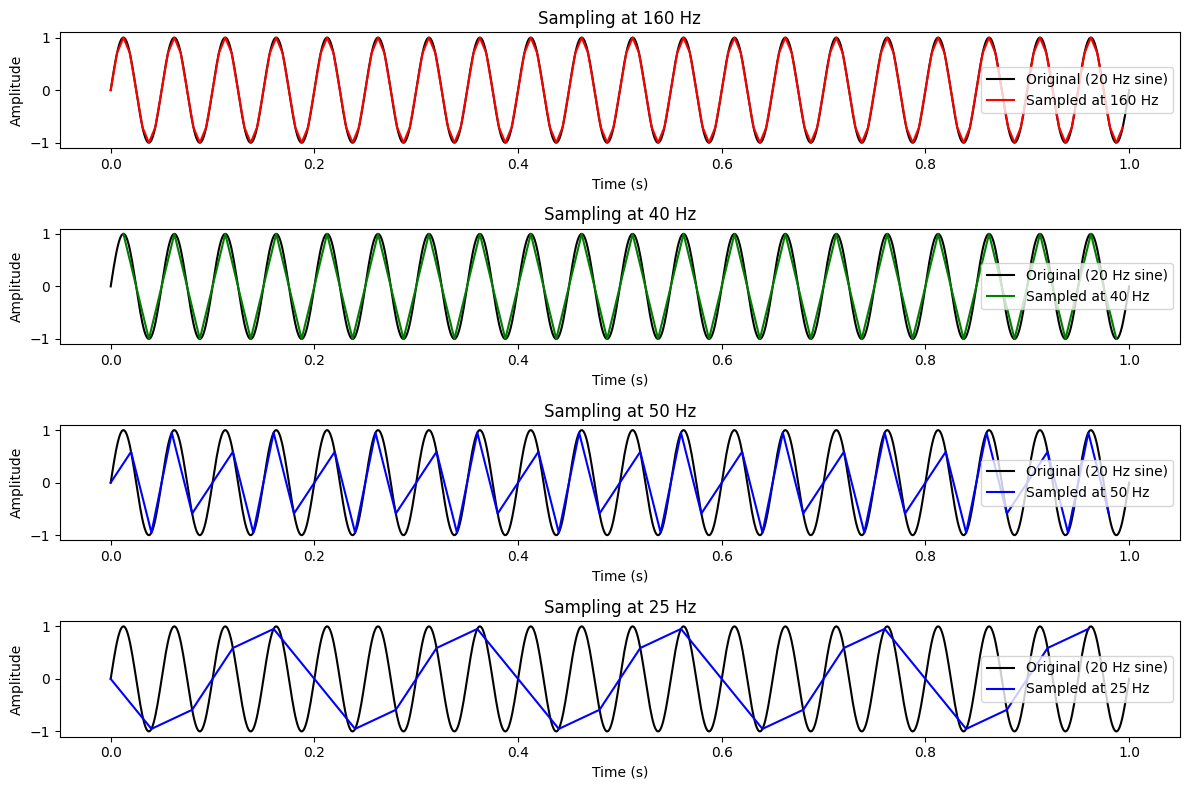

In [ ]:
plt.figure(figsize=(12,8))
for i, fs in enumerate(fs_list, 1):
    n = np.arange(0, 1, 1/fs)
    if fs == 40 : # No need to worry about this if condition now
                  # You can comment this condition and see what happens
        t0 = 1/(4*20)
        n = n + t0
    x_n = np.sin(2*np.pi*20*n)

    plt.subplot(4,1,i)
    plt.plot(t_ct, x_ct, 'k', label="Original (20 Hz sine)")
    plt.plot(n, x_n, colors[i-1], label=f"Sampled at {fs} Hz")


    plt.title(f"Sampling at {fs} Hz")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
    plt.legend()

plt.tight_layout()
plt.show()

Did you notice the fourth subfigure? It shows a lower-frequency version of the original signal — this is called an aliased signal.

According to the Nyquist theorem, the sampling rate must be at least twice the signal frequency to avoid aliasing.
However, just meeting Nyquist is not always enough for clean visualization or practical reconstruction — we often need a higher sampling rate or a rate that aligns with the signal’s period (so samples fall on symmetric points like peaks and zero-crossings).

# Discrete vs Digital Signals

- **Discrete Signal:** Discrete in time, continuous in amplitude  
- **Digital Signal:** Discrete in time, discrete in amplitude  


***Quantization*** is like **sampling in amplitude**.

- **Bit depth (b):** bits/sample  
- **Levels (L):** $L = 2^b$  
- **Step size (Δ):** $\Delta = \frac{\max(x)-\min(x)}{L}$  

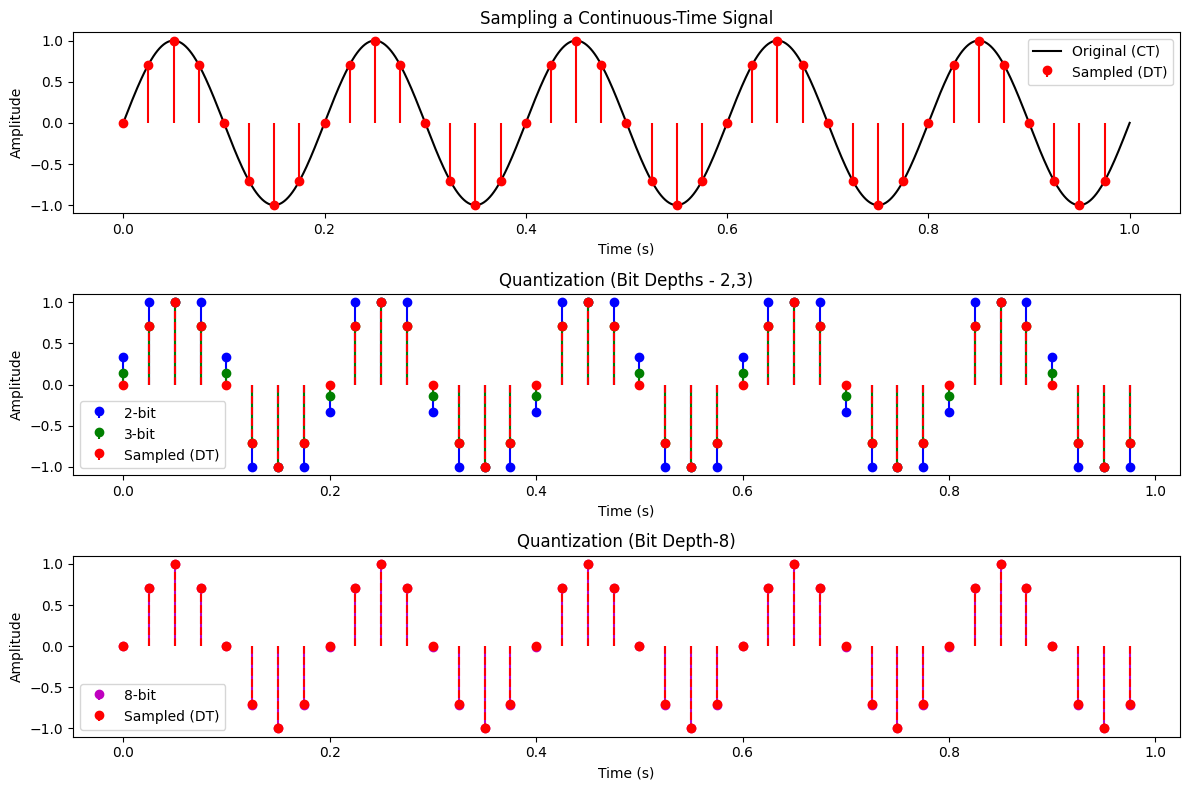

In [ ]:
# Taking a continuous time signal
t_ct = np.linspace(0, 1, 1000)
x_ct = np.sin(2*np.pi*5*t_ct)  # 5 Hz sine

# Sample the signal
fs_sample = 40
n = np.arange(0, 1, 1/fs_sample)
x_sampled = np.sin(2*np.pi*5*n)

# Quantize the sampled signal
# def quantize(signal, bits):
#     levels = 2**bits
#     q_signal = np.round((signal + 1) * (levels-1) / 2)  # map to 0..levels-1
#     q_signal = 2*q_signal/(levels-1) - 1                # back to [-1,1]
#     return q_signal
def quantize(signal, bits):
    L = 2**bits-1

    x_min, x_max = np.min(signal), np.max(signal)
    Δ = (x_max - x_min) / L

    q_signal = np.round((signal - x_min) / Δ) * Δ + x_min

    # # Clip in case of numerical overflow
    # q_signal = np.clip(q_signal, x_min, x_max)

    return q_signal

x_q_2bit = quantize(x_sampled, 2)
x_q_3bit = quantize(x_sampled, 3)
x_q_8bit = quantize(x_sampled, 8)


plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(t_ct, x_ct, 'k', label="Original (CT)")
plt.stem(n, x_sampled, basefmt=" ", linefmt="r-", markerfmt="ro", label="Sampled (DT)")
plt.title("Sampling a Continuous-Time Signal")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.legend()

plt.subplot(3,1,2)
plt.stem(n, x_q_2bit, basefmt=" ", linefmt="b-", markerfmt="bo", label="2-bit")
plt.stem(n, x_q_3bit, basefmt=" ", linefmt="g-", markerfmt="go", label="3-bit")
plt.stem(n, x_sampled, basefmt=" ", linefmt="r--", markerfmt="ro", label="Sampled (DT)")
plt.title("Quantization (Bit Depths - 2,3)")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.legend()

# Higher bit quantization
plt.subplot(3,1,3)
plt.stem(n, x_q_8bit, basefmt=" ", linefmt="m-", markerfmt="mo", label="8-bit")
plt.stem(n, x_sampled, basefmt=" ", linefmt="r--", markerfmt="ro", label="Sampled (DT)")
plt.title("Quantization (Bit Depth-8)")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.legend()

plt.tight_layout()
plt.show()


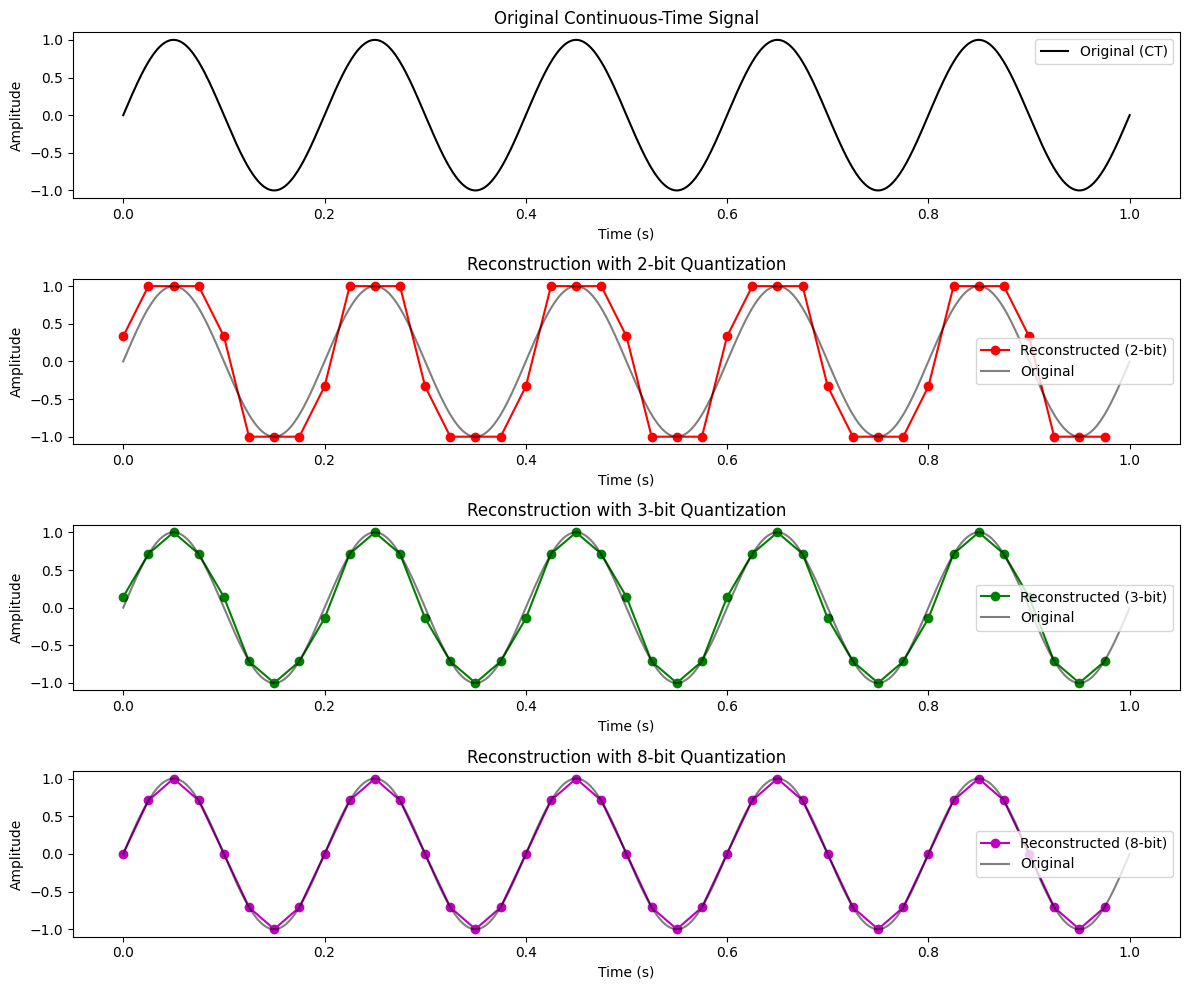

In [ ]:
# Now, reconstruct
plt.figure(figsize=(12,10))

plt.subplot(4,1,1)
plt.plot(t_ct, x_ct, 'k', label="Original (CT)")
plt.title("Original Continuous-Time Signal")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.legend()

plt.subplot(4,1,2)
plt.plot(n, x_q_2bit, 'r-o', label="Reconstructed (2-bit)")
plt.plot(t_ct, x_ct, 'k', alpha=0.5, label="Original")
plt.title("Reconstruction with 2-bit Quantization")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.legend()

plt.subplot(4,1,3)
plt.plot(n, x_q_3bit, 'g-o', label="Reconstructed (3-bit)")
plt.plot(t_ct, x_ct, 'k', alpha=0.5, label="Original")
plt.title("Reconstruction with 3-bit Quantization")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.legend()

plt.subplot(4,1,4)
plt.plot(n, x_q_8bit, 'm-o', label="Reconstructed (8-bit)")
plt.plot(t_ct, x_ct, 'k', alpha=0.5, label="Original")
plt.title("Reconstruction with 8-bit Quantization")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.legend()

plt.tight_layout()
plt.show()



**Quantization error:**  
$\
e[n] = x[n] - x_q[n]
\ $

- Fewer bits → larger error  
- More bits → smaller error  

Example: CD = 16-bit, ECG = 10–12 bits, Blu-ray audio= 24-bit

In [ ]:
for b in [2,3,8]:
    x_q = quantize(x_sampled, b)
    mse = np.mean((x_sampled - x_q)**2)
    print(f"{b}-bit quantization MSE:", mse)


2-bit quantization MSE: 0.07067099659123006
3-bit quantization MSE: 0.0051278093565476105
8-bit quantization MSE: 7.481958245272746e-06


## Basic Signal Operations

In this part, we will learn the fundamental operations on signals:
1. Amplitude Scaling
2. Amplitude Shifting
3. Time Scaling
4. Time Shifting

We will consider both continuous-time (CT) and discrete-time (DT) signals.


## 1. Amplitude Scaling

When all points of a signal are multiplied by a constant β:

- CT:  y(t) = β x(t)  
- DT:  y[n] = β x[n]  

- If |β| > 1 → amplifies  
- If |β| < 1 → compresses  
- If β < 0 → reflection about axis  

**Signal shape remains the same, only amplitude changes.**


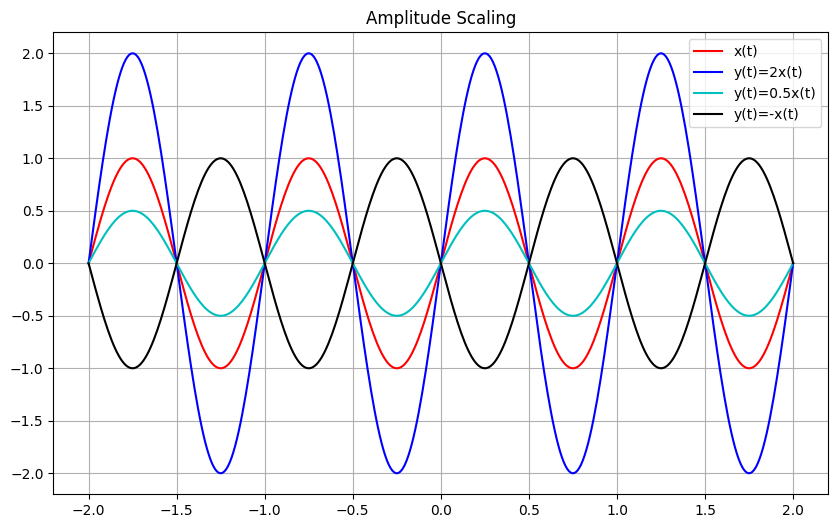

In [ ]:
t = np.linspace(-2, 2, 400)
x = np.sin(2*np.pi*1*t)    # original signal
y1 = 2*x                   # amplification
y2 = 0.5*x                 # compression
y3 = -1*x                  # reflection

plt.figure(figsize=(10,6))
plt.plot(t, x,'r', label="x(t)")
plt.plot(t, y1,'b', label="y(t)=2x(t)")
plt.plot(t, y2,'c', label="y(t)=0.5x(t)")
plt.plot(t, y3,'k', label="y(t)=-x(t)")
plt.legend(); plt.grid(); plt.title("Amplitude Scaling")
plt.show()


**Do you see any change in frequency?**

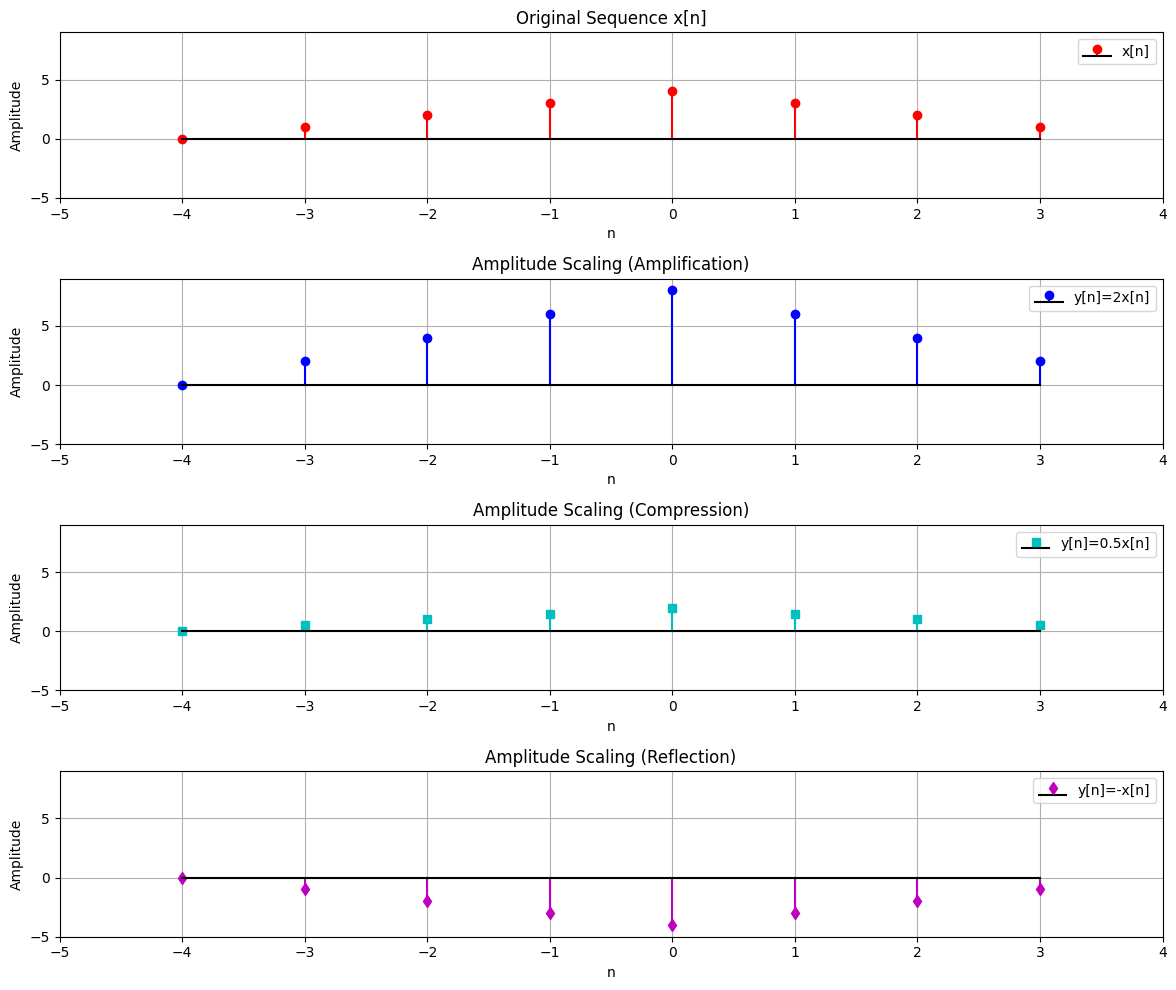

In [ ]:
# Discrete-time signal
n = np.arange(-4, 4)
x_n = np.array([ 0, 1, 2, 3, 4, 3, 2, 1 ])  # original signal

y1_n = 2 * x_n       # amplification
y2_n = 0.5 * x_n     # compression
y3_n = -1 * x_n      # reflection

plt.figure(figsize=(12,10))

plt.subplot(4,1,1)
plt.stem(n, x_n, linefmt='r-', markerfmt='ro', basefmt='k-', label="x[n]")
plt.title("Original Sequence x[n]")
plt.xlabel("n"); plt.ylabel("Amplitude")
plt.legend(); plt.grid()
plt.xlim([-5, 4])
plt.ylim([-5, 9])

plt.subplot(4,1,2)
plt.stem(n, y1_n, linefmt='b-', markerfmt='bo', basefmt='k-', label="y[n]=2x[n]")
plt.title("Amplitude Scaling (Amplification)")
plt.xlabel("n"); plt.ylabel("Amplitude")
plt.legend(); plt.grid()
plt.xlim([-5, 4])
plt.ylim([-5, 9])

plt.subplot(4,1,3)
plt.stem(n, y2_n, linefmt='c-', markerfmt='cs', basefmt='k-', label="y[n]=0.5x[n]")
plt.title("Amplitude Scaling (Compression)")
plt.xlabel("n"); plt.ylabel("Amplitude")
plt.legend(); plt.grid()
plt.xlim([-5, 4])
plt.ylim([-5, 9])

plt.subplot(4,1,4)
plt.stem(n, y3_n, linefmt='m-', markerfmt='md', basefmt='k-', label="y[n]=-x[n]")
plt.title("Amplitude Scaling (Reflection)")
plt.xlabel("n"); plt.ylabel("Amplitude")
plt.legend(); plt.grid()
plt.xlim([-5, 4])
plt.ylim([-5, 9])


plt.tight_layout()
plt.show()

## 2. Amplitude Shifting

When a constant value `c` is added to a signal:

- CT:  y(t) = x(t) + c  
- DT:  y[n] = x[n] + c  

- c > 0 → shifts upward  
- c < 0 → shifts downward  


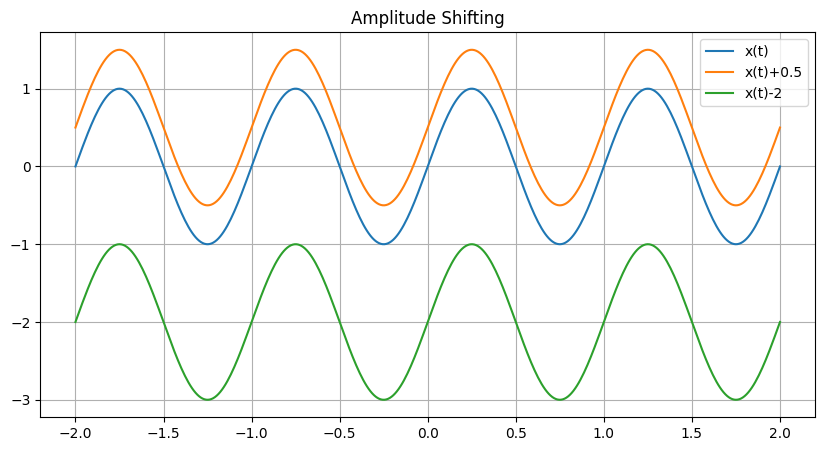

In [ ]:
x = np.sin(2*np.pi*1*t)
y1 = x + .5   # upward shift
y2 = x - 2   # downward shift

plt.figure(figsize=(10,5))
plt.plot(t, x, label="x(t)")
plt.plot(t, y1, label="x(t)+0.5")
plt.plot(t, y2, label="x(t)-2")
plt.legend(); plt.grid(); plt.title("Amplitude Shifting")
plt.show()


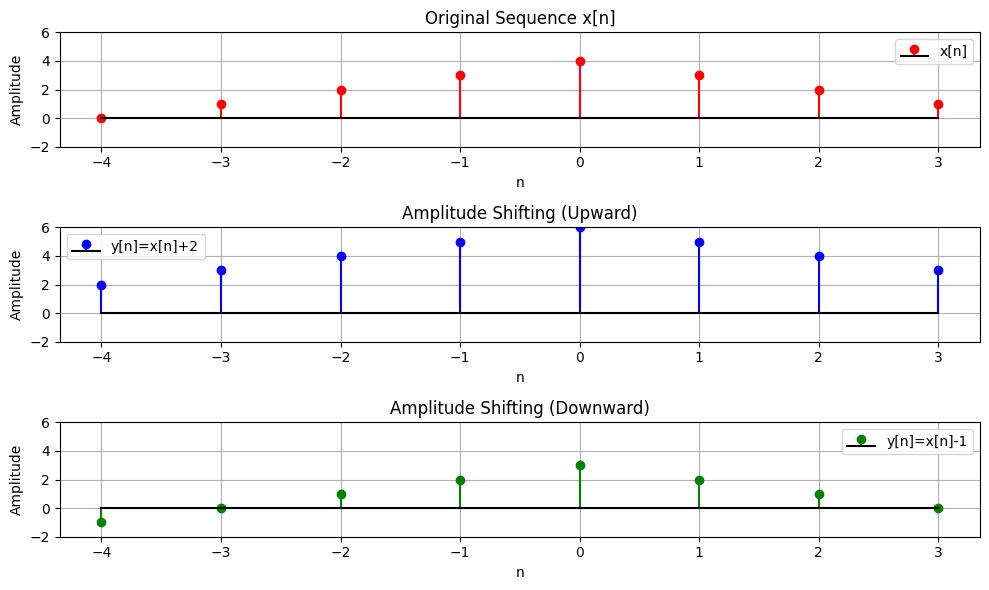

In [ ]:
# Discrete-time signal
n = np.arange(-4, 4)
x_n = np.array([ 0, 1, 2, 3, 4, 3, 2, 1 ])  # original signal

# Amplitude shifting
y1_n = x_n + 2   # upward shift
y2_n = x_n - 1   # downward shift

plt.figure(figsize=(10, 6))

plt.subplot(3,1,1)
plt.ylim([-2, 6])
plt.stem(n, x_n, linefmt='r-', markerfmt='ro', basefmt='k-', label="x[n]")
plt.title("Original Sequence x[n]")
plt.xlabel("n"); plt.ylabel("Amplitude")
plt.legend(); plt.grid()

plt.subplot(3,1,2)
plt.ylim([-2, 6])
plt.stem(n, y1_n, linefmt='b-', markerfmt='bo', basefmt='k-', label="y[n]=x[n]+2")
plt.title("Amplitude Shifting (Upward)")
plt.xlabel("n"); plt.ylabel("Amplitude")
plt.legend(); plt.grid()

plt.subplot(3,1,3)
plt.ylim([-2, 6])
plt.stem(n, y2_n, linefmt='g-', markerfmt='go', basefmt='k-', label="y[n]=x[n]-1")
plt.title("Amplitude Shifting (Downward)")
plt.xlabel("n"); plt.ylabel("Amplitude")
plt.legend(); plt.grid()

plt.tight_layout()
plt.show()

## 3. Time Scaling

Multiply the time variable by a factor α:

- CT:  y(t) = x(αt)  
- DT:  y[n] = x[αn]  

- |α| > 1 → compression in time  
- |α| < 1 → expansion in time  
- α < 0 → time reversal  

N:B:  
- CT signals → scaling is reversible  
- DT signals → scaling may lose samples (not reversible)  


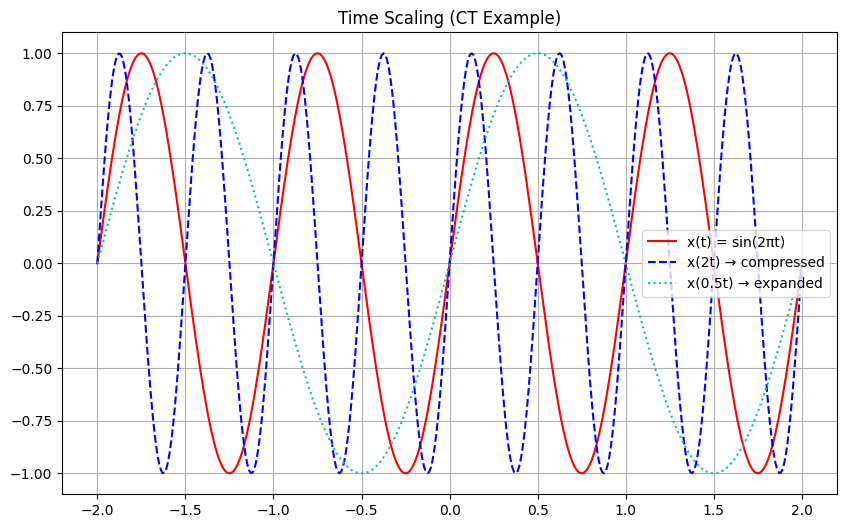

In [ ]:
x = np.sin(2*np.pi*1*t)  # 1 Hz sine
y1 = np.sin(2*np.pi*1*2*t)   # α=2 → compressed (2 Hz)
y2 = np.sin(2*np.pi*1*0.5*t) # α=0.5 → expanded (0.5 Hz)

plt.figure(figsize=(10,6))
plt.plot(t, x,'r', label="x(t) = sin(2πt)")
plt.plot(t, y1,'b--', label="x(2t) → compressed")
plt.plot(t, y2,'c:', label="x(0.5t) → expanded")
plt.legend(); plt.grid(); plt.title("Time Scaling (CT Example)")
plt.show()

Do you see any change in frequency **now**?

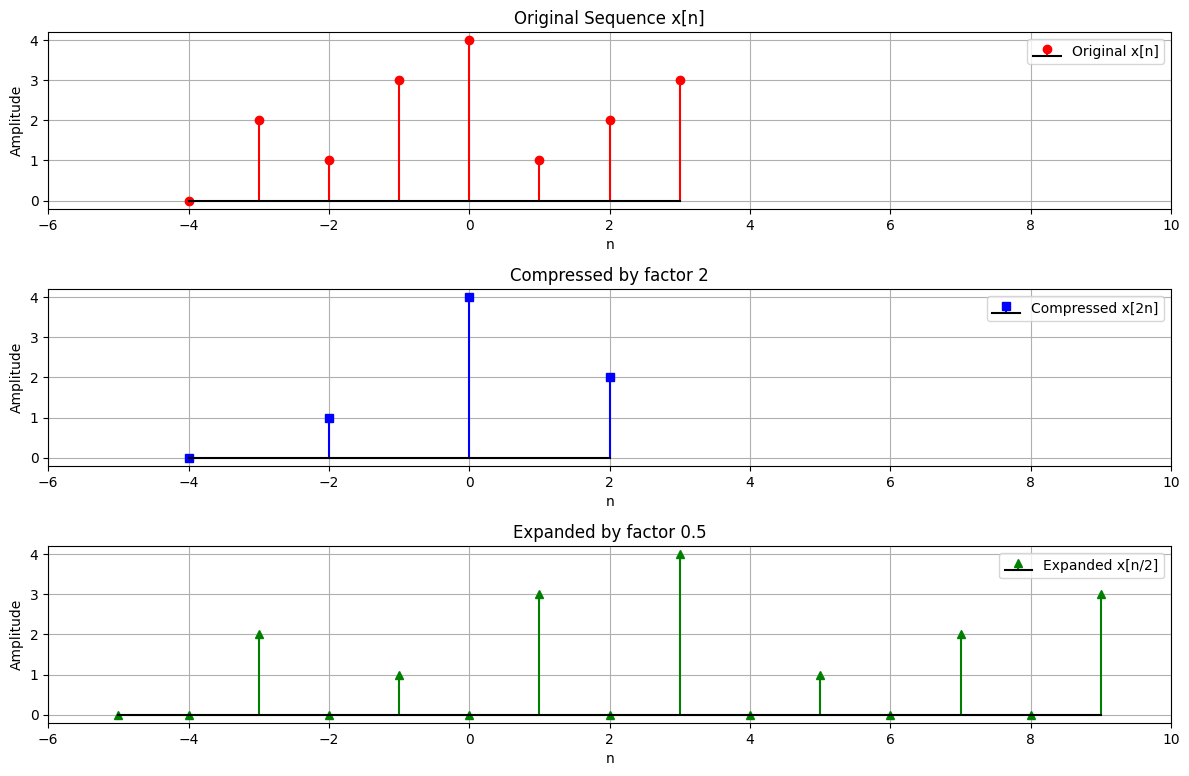

In [ ]:
# Original DT signal (triangular)
n = np.arange(-4, 4)
x_n = np.array([ 0, 2, 1, 3, 4, 1, 2, 3 ])  # original signal

# Compression (α=2): x[2n] → keep even indices
n_compress = n[::2]
x_compress = x_n[::2]

# Expansion (α=0.5): insert zeros
n_expand = np.arange(n[0]*2, n[-1]*2+1) / 2
x_expand = np.zeros(len(n_expand), dtype=int)
x_expand[::2] = x_n

# Plot all
plt.figure(figsize=(12,10))

plt.subplot(4,1,1)
plt.xlim([-6, 10])
plt.stem(n, x_n, linefmt='r-', markerfmt='ro', basefmt='k-', label="Original x[n]")
plt.title("Original Sequence x[n]")
plt.xlabel("n"); plt.ylabel("Amplitude")
plt.legend(); plt.grid()

plt.subplot(4,1,2)
plt.xlim([-6, 10])
plt.stem(n_compress, x_compress, linefmt='b-', markerfmt='bs', basefmt='k-', label="Compressed x[2n]")
plt.title("Compressed by factor 2")
plt.xlabel("n"); plt.ylabel("Amplitude")
plt.legend(); plt.grid()

plt.subplot(4,1,3)
plt.xlim([-6, 10])
plt.stem(np.arange(len(x_expand))-5, x_expand, linefmt='g-', markerfmt='g^', basefmt='k-', label="Expanded x[n/2]")
plt.title("Expanded by factor 0.5")
plt.xlabel("n"); plt.ylabel("Amplitude")
plt.legend(); plt.grid()



plt.tight_layout()
plt.show()

Can you sense any issue in expansion here?

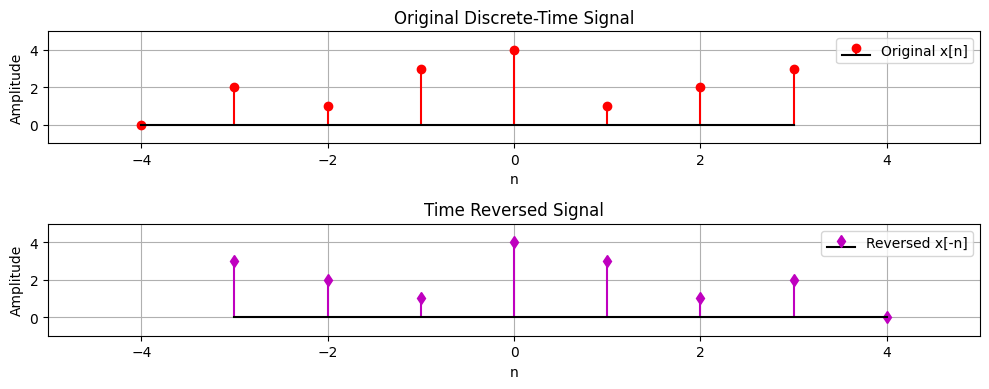

In [ ]:
x_reverse_alter=x_n[::-1]
# Need to create a time axis for the reversed signal.
# Since the original signal was from n=-4 to 3, the reversed signal will be from -3 to 4.
n_reverse_alter = np.arange(-n[-1], -n[0] + 1)
plt.figure(figsize=(10, 4))

plt.subplot(2, 1, 1)
plt.stem(n, x_n, linefmt='r-', markerfmt='ro', basefmt='k-', label="Original x[n]")
plt.title("Original Discrete-Time Signal")
plt.xlabel("n"); plt.ylabel("Amplitude")
plt.legend(); plt.grid()
plt.xlim([-5, 5])
plt.ylim([-1, 5])

plt.subplot(2, 1, 2)

plt.stem(n_reverse_alter, x_reverse_alter, linefmt='m-', markerfmt='md', basefmt='k-', label="Reversed x[-n]")
plt.title("Time Reversed Signal")
plt.xlabel("n"); plt.ylabel("Amplitude")
plt.legend(); plt.grid()
plt.xlim([-5, 5])
plt.ylim([-1, 5])


plt.tight_layout()
plt.show()

## 4. Time Shifting

Add constant `c` (CT) or integer `k` (DT) to the time variable:

- CT:  y(t) = x(t - c)  
- DT:  y[n] = x[n - k]  

- c > 0 (or k > 0) → right shift (delay)  
- c < 0 (or k < 0) → left shift (advance)  

N:B: Discrete signals can only be shifted by integers.


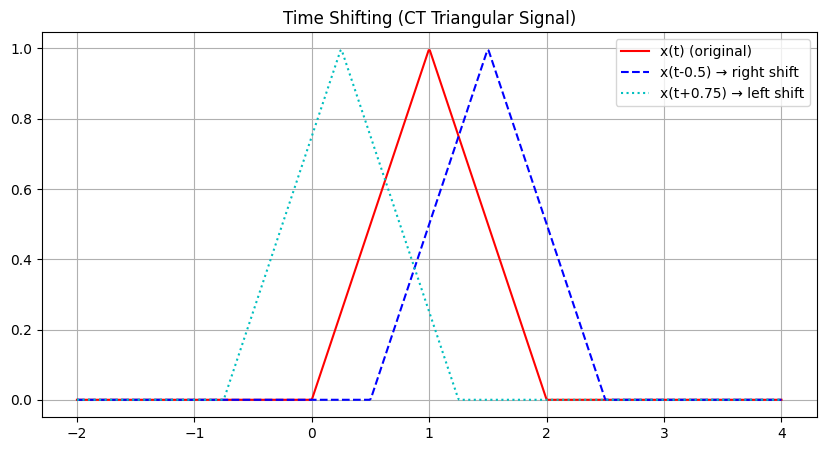

In [ ]:
# Define time axis
t = np.linspace(-2, 4, 600)

# Define a finite triangular signal
def triangular(t):
    y = np.zeros_like(t)
    for i, val in enumerate(t):
        if 0 <= val < 1:
            y[i] = val
        elif 1 <= val <= 2:
            y[i] = 2 - val
    return y

x = triangular(t)                       # original
y_ct = triangular(t - 0.5)              # right shift by 0.5
y_ct2 = triangular(t + 0.75)            # left shift by 0.75

# Plotting
plt.figure(figsize=(10,5))
plt.plot(t, x, 'r', label="x(t) (original)")
plt.plot(t, y_ct, 'b--', label="x(t-0.5) → right shift")
plt.plot(t, y_ct2, 'c:', label="x(t+0.75) → left shift")
plt.legend(); plt.grid(); plt.title("Time Shifting (CT Triangular Signal)")
plt.show()


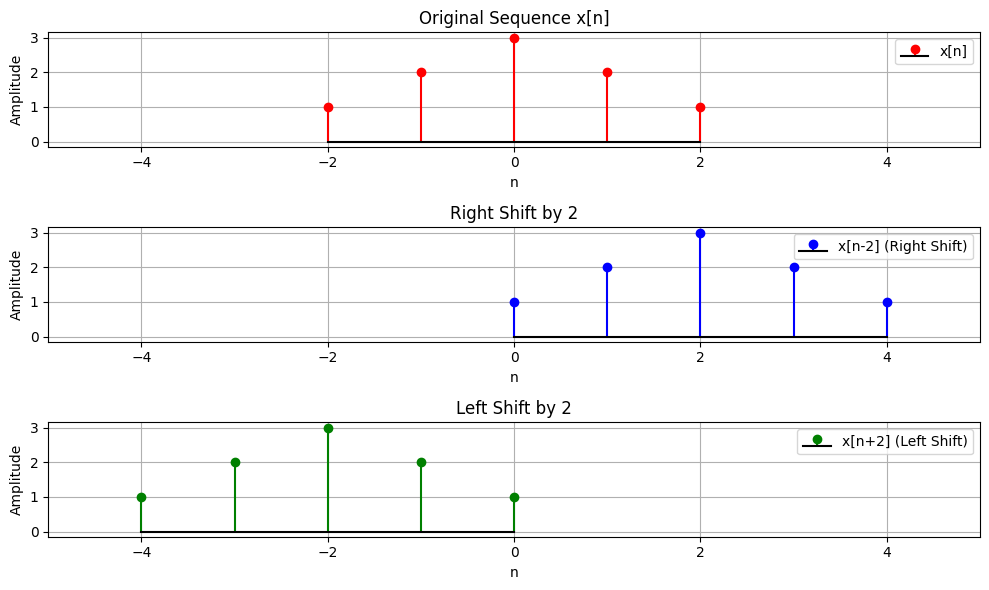

In [ ]:
# Discrete-time signal
n = np.arange(-2, 3)
x_n = np.array([1, 2, 3, 2, 1])
k = 2  # shift amount

# Right shift (delay): x[n - k]
n_right = n + k   # shifting right increases index values
y_right = x_n

# Left shift (advance): x[n + k]
n_left = n - k    # shifting left decreases index values
y_left = x_n

plt.figure(figsize=(10,6))
plt.subplot(3,1,1)
plt.stem(n, x_n, linefmt='r-', markerfmt='ro', basefmt='k-', label='x[n]')
plt.title('Original Sequence x[n]')
plt.xlabel('n'); plt.ylabel('Amplitude')
plt.legend(); plt.grid(True)
plt.xlim([-5, 5])

plt.subplot(3,1,2)
plt.stem(n_right, y_right, linefmt='b-', markerfmt='bo', basefmt='k-', label='x[n-2] (Right Shift)')
plt.title('Right Shift by 2')
plt.xlabel('n'); plt.ylabel('Amplitude')
plt.legend(); plt.grid(True)
plt.xlim([-5, 5])

plt.subplot(3,1,3)
plt.stem(n_left, y_left, linefmt='g-', markerfmt='go', basefmt='k-', label='x[n+2] (Left Shift)')
plt.title('Left Shift by 2')
plt.xlabel('n'); plt.ylabel('Amplitude')
plt.legend(); plt.grid(True)
plt.xlim([-5, 5])

plt.tight_layout()
plt.show()


## Real-life signal
Now, we will load a recorded audio, visualize the signal and and implement the theories to observe real effects. I have added a recording here as an example.

In [ ]:
import librosa
import librosa.display


# Load the audio file
audio_path = "/content/Recording.m4a"
signal, sr = librosa.load(audio_path, sr=None)

# Display basic information
print(" Audio loaded successfully!")
print(f"Sampling rate: {sr} Hz")
print(f"Total samples: {len(signal)}")
print(f"Duration: {len(signal)/sr:.2f} seconds")


/tmp/ipython-input-1493793045.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(audio_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


 Audio loaded successfully!
Sampling rate: 48000 Hz
Total samples: 331776
Duration: 6.91 seconds


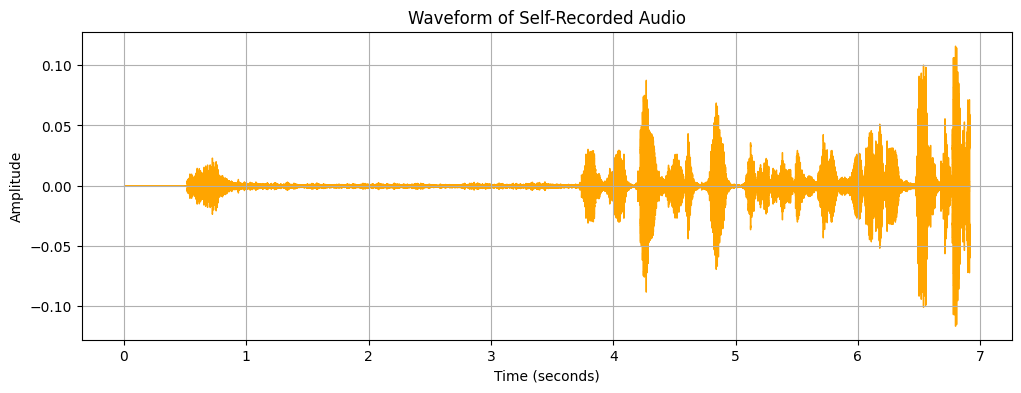

In [ ]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(signal, sr=sr, color='orange')
plt.title("Waveform of Self-Recorded Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


In [ ]:
import IPython.display as ipd


# Play Original Audio
print("Original Audio")
ipd.display(ipd.Audio(signal, rate=sr))

# Time Scaling
signal_compress = signal[::2]
signal_expanded = np.repeat(signal, 2)  # It is a bit different from inserting
                                        # zeros as we have seen earlier, this
                                        # process repeats the sample twice

print("\n Compressed Audio")
ipd.display(ipd.Audio(signal_compress, rate=sr))

print(" Expanded Audio")
ipd.display(ipd.Audio(signal_expanded, rate=sr))


Original Audio



 Compressed Audio


 Expanded Audio


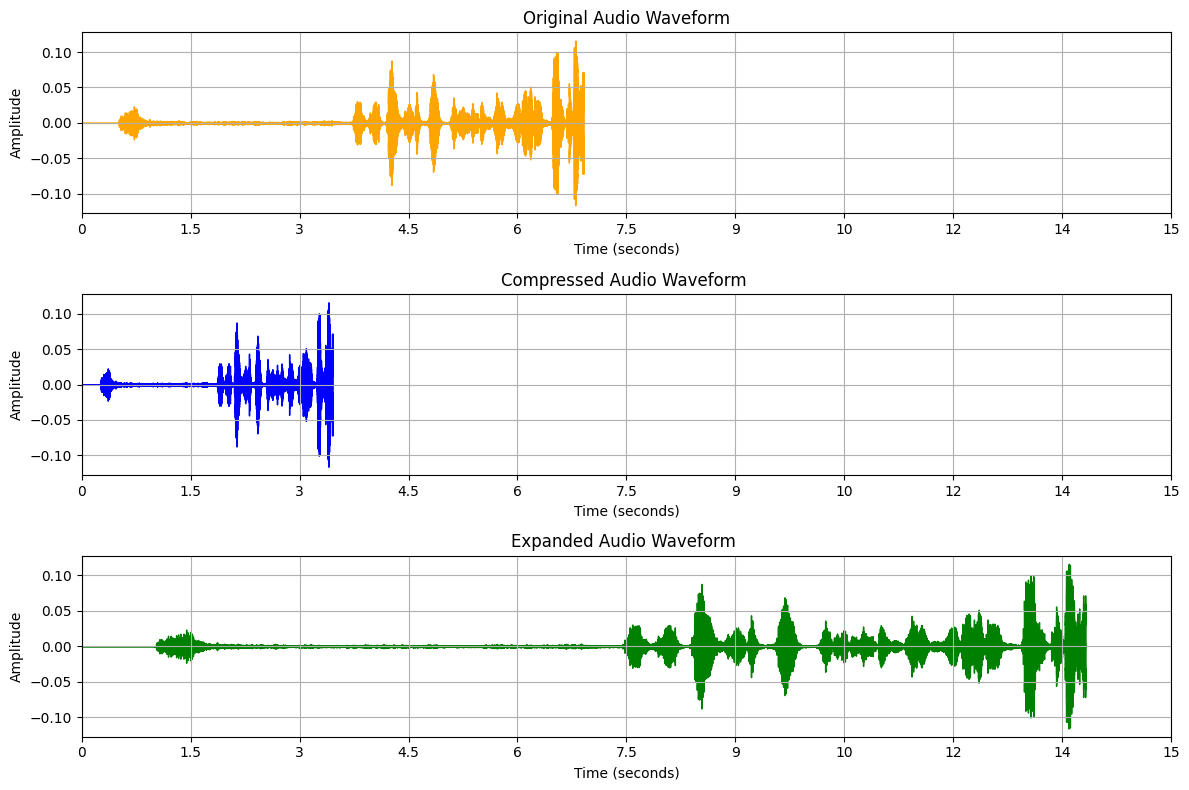

In [ ]:
plt.figure(figsize=(12, 8))

# Plot Original Audio
plt.subplot(3, 1, 1)
plt.xlim([0,15])
librosa.display.waveshow(signal, sr=sr, color='orange')
plt.title("Original Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Plot Compressed Audio
plt.subplot(3, 1, 2)
plt.xlim([0,15])
librosa.display.waveshow(signal_compress, sr=sr, color='blue')
plt.title("Compressed Audio Waveform ")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Plot Expanded Audio
plt.subplot(3, 1, 3)
plt.xlim([0,15])
librosa.display.waveshow(signal_expanded, sr=sr, color='green')
plt.title("Expanded Audio Waveform ")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

When we compress or expand an audio signal by skipping or repeating samples, we change how fast the waveform plays without filling in the missing parts correctly.

**Compressed signal (x[2n])** → plays faster than normal, so the sound becomes shorter and sharper.

**Expanded signal (x[n/2])** → plays slower, so the sound becomes longer and stretched, sometimes with gaps or distortion.

These changes happen because we did not rebuild the signal smoothly — we only changed how quickly samples are played.

In [ ]:
signal_resample_fast = librosa.effects.time_stretch(signal, rate=2.0)
signal_resample_slow = librosa.effects.time_stretch(signal, rate=0.5)


In [ ]:
print("\n Resampled Faster (2× speed)")
ipd.display(ipd.Audio(signal_resample_fast, rate=sr))

print("\n Resampled Slower (0.5× speed)")
ipd.display(ipd.Audio(signal_resample_slow, rate=sr))



 Resampled Faster (2× speed)



 Resampled Slower (0.5× speed)


Resampling properly adjusts the number and spacing of samples so the waveform stays smooth.
It fills in or removes samples carefully using interpolation, keeping the sound natural and clear even when played faster or slower.